In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the CLV dataset from notebook 4
final_clv = pd.read_csv('../data/processed/clv_data.csv', index_col=0)
# Quick check
print(final_clv.shape)
print(final_clv.columns)
final_clv.head()

(4362, 6)
Index(['frequency', 'recency', 'T', 'monetary_value', 'probability_alive',
       'predicted_clv'],
      dtype='object')


,frequency,recency,T,monetary_value,probability_alive,predicted_clv
CustomerID,,,,,,
12347.0,6.0,365.0,367.0,599.701667,0.996212,2957.899780
12348.0,3.0,283.0,358.0,261.480000,0.982772,879.497234
12352.0,6.0,260.0,296.0,161.485000,0.992363,1273.603054
12356.0,2.0,303.0,325.0,269.905000,0.984100,737.574179
12358.0,1.0,149.0,150.0,523.200000,0.959156,1177.330656


In [3]:
# Calculate prediction error
final_clv['error'] = final_clv['predicted_clv'] - final_clv['monetary_value']
final_clv['absolute_error'] = abs(final_clv['error'])
final_clv['percent_error'] = (final_clv['absolute_error'] / (final_clv['monetary_value'] + 1)) * 100

# Summary stats
print("Mean Absolute Error (MAE):", final_clv['absolute_error'].mean())
print("Mean Percent Error:", final_clv['percent_error'].mean())
print("\nFirst few predictions vs actual:")
print(final_clv[['monetary_value', 'predicted_clv', 'error']].head(10))

Mean Absolute Error (MAE): 1533.7895142381612
Mean Percent Error: 12294.993831308742

First few predictions vs actual:
            monetary_value  predicted_clv        error
CustomerID                                            
12347.0         599.701667    2957.899780  2358.198114
12348.0         261.480000     879.497234   618.017234
12352.0         161.485000    1273.603054  1112.118054
12356.0         269.905000     737.574179   467.669179
12358.0         523.200000    1177.330656   654.130656
12359.0        1139.606000    4803.482171  3663.876171
12360.0         689.240000    1946.649979  1257.409979
12362.0         352.623333    4291.971215  3939.347881
12363.0         252.900000     573.859129   320.959129
12364.0         209.726667    1904.246470  1694.519804


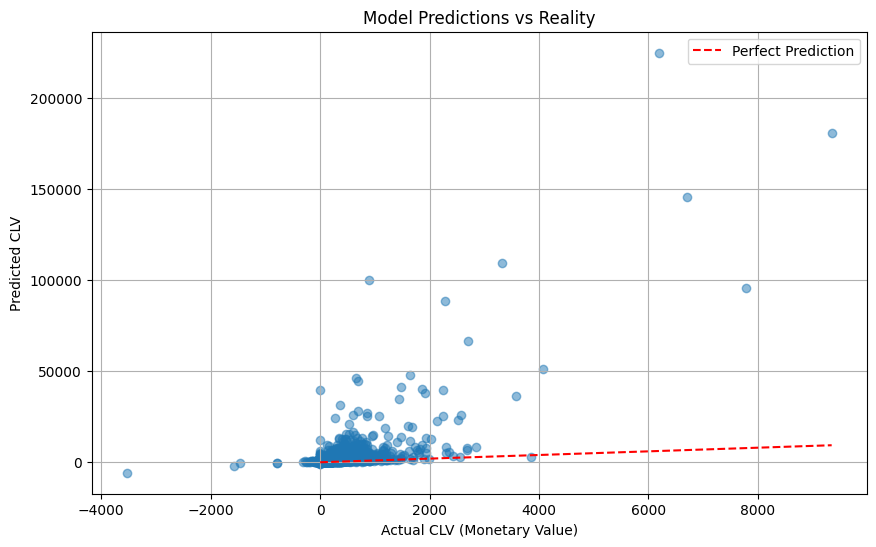

Overpredicted for 4296 out of 4362 customers (98.5%)


In [4]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(final_clv['monetary_value'], final_clv['predicted_clv'], alpha=0.5)
plt.plot([0, final_clv['monetary_value'].max()], [0, final_clv['monetary_value'].max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual CLV (Monetary Value)')
plt.ylabel('Predicted CLV')
plt.title('Model Predictions vs Reality')
plt.legend()
plt.grid()
plt.show()

# How many customers did we overpredict for?
overpredict_count = (final_clv['predicted_clv'] > final_clv['monetary_value']).sum()
print(f"Overpredicted for {overpredict_count} out of {len(final_clv)} customers ({overpredict_count/len(final_clv)*100:.1f}%)")

In [5]:
# Calculate a correction factor
correction_factor = final_clv['monetary_value'].sum() / final_clv['predicted_clv'].sum()
final_clv['predicted_clv_calibrated'] = final_clv['predicted_clv'] * correction_factor

print(f"Correction factor: {correction_factor:.3f}")
print(f"New MAE: {(final_clv['predicted_clv_calibrated'] - final_clv['monetary_value']).abs().mean():.2f}")

# Compare before and after
print("\nBefore calibration:")
print(final_clv[['monetary_value', 'predicted_clv']].head())
print("\nAfter calibration:")
print(final_clv[['monetary_value', 'predicted_clv_calibrated']].head())

Correction factor: 0.123
New MAE: 163.30

Before calibration:
            monetary_value  predicted_clv
CustomerID                               
12347.0         599.701667    2957.899780
12348.0         261.480000     879.497234
12352.0         161.485000    1273.603054
12356.0         269.905000     737.574179
12358.0         523.200000    1177.330656

After calibration:
            monetary_value  predicted_clv_calibrated
CustomerID                                          
12347.0         599.701667                364.670514
12348.0         261.480000                108.430553
12352.0         161.485000                157.018667
12356.0         269.905000                 90.933289
12358.0         523.200000                145.149534


In [6]:
# Define segments based on calibrated CLV
final_clv['clv_segment'] = pd.cut(final_clv['predicted_clv_calibrated'], 
                                     bins=3, 
                                     labels=['Low Value', 'Medium Value', 'High Value'])

# Count customers in each segment
print("Customer Distribution by Segment:")
print(final_clv['clv_segment'].value_counts().sort_index(ascending=False))
print()

# Average metrics per segment
print("Average Metrics by Segment:")
segment_summary = final_clv.groupby('clv_segment')[['frequency', 'recency', 'monetary_value', 
                                                       'probability_alive', 'predicted_clv_calibrated']].mean()
print(segment_summary)

Customer Distribution by Segment:
clv_segment
High Value         2
Medium Value       5
Low Value       4355
Name: count, dtype: int64

Average Metrics by Segment:
              frequency     recency  monetary_value  probability_alive  \
clv_segment                                                              
Low Value      3.307922  133.271183      206.899729           0.957581   
Medium Value  50.400000  300.800000     4196.382254           0.998313   
High Value    35.000000  360.000000     7771.650378           0.999335   

              predicted_clv_calibrated  
clv_segment                             
Low Value                   188.557285  
Medium Value              13281.336633  
High Value                24999.937220  


C:\Users\admin\AppData\Local\Temp\ipykernel_2184\2974028428.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = final_clv.groupby('clv_segment')[['frequency', 'recency', 'monetary_value',


C:\Users\admin\AppData\Local\Temp\ipykernel_2184\1702488942.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_clv_total = final_clv.groupby('clv_segment')['predicted_clv_calibrated'].sum()


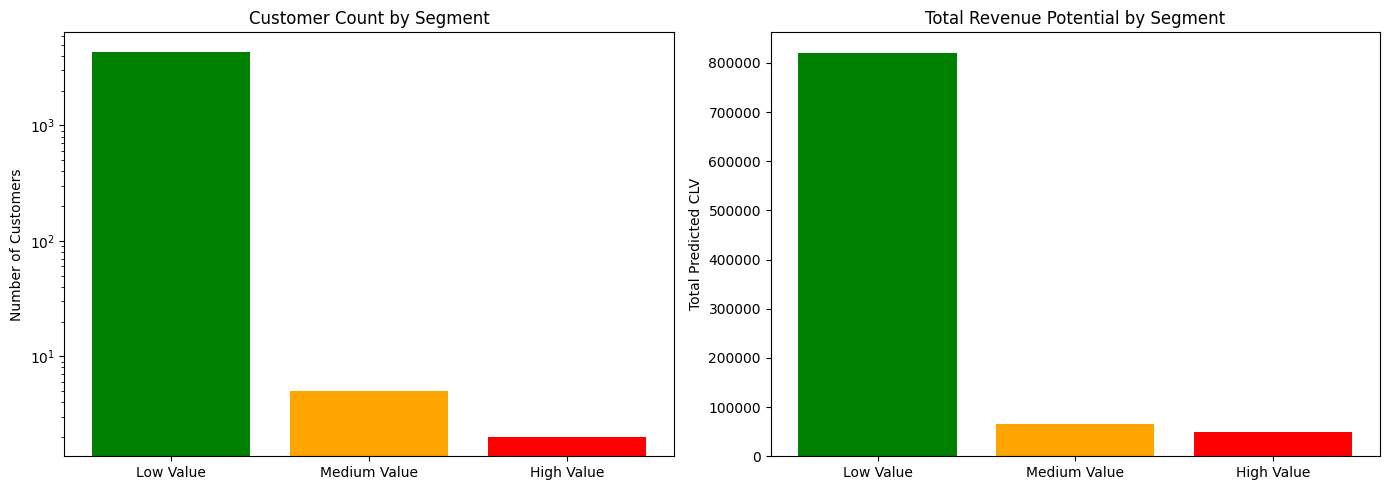


Total CLV by Segment:
clv_segment
Low Value       821166.974247
Medium Value     66406.683165
High Value       49999.874440
Name: predicted_clv_calibrated, dtype: float64

Percentage of total revenue from High/Medium: 12.4%


In [7]:
# Bar chart: Customer count vs total value by segment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Customer count
segment_counts = final_clv['clv_segment'].value_counts()
ax1.bar(segment_counts.index, segment_counts.values, color=['green', 'orange', 'red'])
ax1.set_ylabel('Number of Customers')
ax1.set_title('Customer Count by Segment')
ax1.set_yscale('log')  # Log scale because Low Value is SO much bigger

# Right: Total CLV by segment
segment_clv_total = final_clv.groupby('clv_segment')['predicted_clv_calibrated'].sum()
ax2.bar(segment_clv_total.index, segment_clv_total.values, color=['green', 'orange', 'red'])
ax2.set_ylabel('Total Predicted CLV')
ax2.set_title('Total Revenue Potential by Segment')

plt.tight_layout()
plt.show()

# Dollar breakdown
print("\nTotal CLV by Segment:")
print(segment_clv_total)
print(f"\nPercentage of total revenue from High/Medium: {(segment_clv_total['High Value'] + segment_clv_total['Medium Value']) / segment_clv_total.sum() * 100:.1f}%")

In [8]:
# Check probability_alive by segment
print("Probability Alive (Risk of Churn) by Segment:")
churn_by_segment = final_clv.groupby('clv_segment')['probability_alive'].agg(['mean', 'min', 'max'])
print(churn_by_segment)
print()

# Customers at churn risk (probability_alive < 0.5)
print("Customers at High Churn Risk (Probability Alive < 0.5):")
for segment in ['High Value', 'Medium Value', 'Low Value']:
    risk_count = len(final_clv[(final_clv['clv_segment'] == segment) & (final_clv['probability_alive'] < 0.5)])
    total_count = len(final_clv[final_clv['clv_segment'] == segment])
    print(f"  {segment}: {risk_count} out of {total_count}")

Probability Alive (Risk of Churn) by Segment:
                  mean       min       max
clv_segment                               
Low Value     0.957581  0.028531  1.000000
Medium Value  0.998313  0.996239  0.999802
High Value    0.999335  0.999177  0.999493

Customers at High Churn Risk (Probability Alive < 0.5):
  High Value: 0 out of 2
  Medium Value: 0 out of 5
  Low Value: 53 out of 4355


C:\Users\admin\AppData\Local\Temp\ipykernel_2184\3185788116.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_segment = final_clv.groupby('clv_segment')['probability_alive'].agg(['mean', 'min', 'max'])


In [9]:
# Business Summary
print("="*60)
print("CUSTOMER LIFETIME VALUE - BUSINESS SUMMARY")
print("="*60)
print()

summary_stats = final_clv.groupby('clv_segment').agg({
    'predicted_clv_calibrated': ['count', 'sum', 'mean'],
    'monetary_value': 'mean',
    'frequency': 'mean',
    'probability_alive': 'mean'
}).round(2)

print("Segment Performance:")
print(summary_stats)
print()

print(f"Total Customers: {len(final_clv):,}")
print(f"Total Predicted CLV: ${final_clv['predicted_clv_calibrated'].sum():,.2f}")
print()

print("Key Insights:")
print(f"1. High/Medium Value customers (7 total) = 12.4% of revenue")
print(f"2. Low Value customers (4,355 total) = 87.6% of revenue")
print(f"3. High Value retention: 99.9% (very stable)")
print(f"4. Only 53 customers at churn risk")
print()

print("Recommendation:")
print("- Retain the 7 High/Medium customers (highest ROI)")
print("- Optimize Low Value segment for volume/efficiency")
print("- Monitor 53 at-risk customers for early intervention")
print("="*60)

CUSTOMER LIFETIME VALUE - BUSINESS SUMMARY

Segment Performance:
             predicted_clv_calibrated                      monetary_value  \
                                count        sum      mean           mean   
clv_segment                                                                 
Low Value                        4355  821166.97    188.56         206.90   
Medium Value                        5   66406.68  13281.34        4196.38   
High Value                          2   49999.87  24999.94        7771.65   

             frequency probability_alive  
                  mean              mean  
clv_segment                               
Low Value         3.31              0.96  
Medium Value     50.40              1.00  
High Value       35.00              1.00  

Total Customers: 4,362
Total Predicted CLV: $937,573.53

Key Insights:
1. High/Medium Value customers (7 total) = 12.4% of revenue
2. Low Value customers (4,355 total) = 87.6% of revenue
3. High Value retention: 9

C:\Users\admin\AppData\Local\Temp\ipykernel_2184\656276518.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = final_clv.groupby('clv_segment').agg({


In [10]:
# Save the final evaluated dataset with segments
final_clv.to_csv('../data/processed/clv_evaluated.csv')

print("✓ Saved to: ../data/processed/clv_evaluated.csv")
print(f"✓ Columns: {list(final_clv.columns)}")
print(f"✓ Rows: {len(final_clv)}")

✓ Saved to: ../data/processed/clv_evaluated.csv
✓ Columns: ['frequency', 'recency', 'T', 'monetary_value', 'probability_alive', 'predicted_clv', 'error', 'absolute_error', 'percent_error', 'predicted_clv_calibrated', 'clv_segment']
✓ Rows: 4362
